In [451]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from scipy import stats

sc = StandardScaler()
plt.style.use('seaborn-v0_8-pastel')

In [452]:
# import data: 2000 US natality data
natality_raw = pd.read_stata('/Users/katharinefbixby/Library/CloudStorage/OneDrive-Personal/Dartmouth/PH141 Regression/natality2000us.dta')

In [470]:
# how many observations
print(len(natality_raw))
# how many variables
print(len(natality_raw.columns))

# descriptive statistics of birthweight excluding unknowns
print(natality_raw.loc[natality_raw['dbirwt'] != 9999, 'dbirwt'].describe())
# descriptive statistics of prenatal visits excluding unknowns
print(natality_raw.loc[natality_raw['nprevis'] != 99, 'nprevis'].describe())
# descriptive statistics of mother's age
print(natality_raw['dmage'].describe())
# descriptive statistics of smokign status
print(natality_raw['tobacco'].value_counts())

4063823
203
count    4.058963e+06
mean     3.316594e+03
std      6.069851e+02
min      2.270000e+02
25%      3.005000e+03
50%      3.350000e+03
75%      3.686000e+03
max      8.136000e+03
Name: dbirwt, dtype: float64
count    3.915299e+06
mean     1.155848e+01
std      4.042997e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.200000e+01
75%      1.400000e+01
max      4.900000e+01
Name: nprevis, dtype: float64
count    4.063823e+06
mean     2.717577e+01
std      6.194412e+00
min      1.000000e+01
25%      2.200000e+01
50%      2.700000e+01
75%      3.200000e+01
max      5.400000e+01
Name: dmage, dtype: float64
tobacco
2    3063533
9     575188
1     425102
Name: count, dtype: int64


In [471]:
# create dichotomous smoking variable
natality_raw['smoker'] = np.where((natality_raw[['tobacco']] == 1).any(axis=1), 1, 0)
# reassign sex to 0 & 1
natality_raw['bsex'] = np.where((natality_raw[['csex']] == 2).any(axis=1), 1, 0)

# select NYC only
natality_nyc = natality_raw[(natality_raw['stnatexp'] == '34')]

# filtered dataframe columns
natality_trim = natality_nyc[['dbirwt', 'bsex', 'dmage', 'wtgain', 'dgestat', 'smoker']]

# filter out unknowns and limit birthweight
natality = natality_trim[(natality_trim['dbirwt'] != 9999) & (natality_trim['wtgain'] != 99) & (natality_trim['dgestat'] != 99)
                             & (natality_trim['dbirwt'] >= 0) & (natality_trim['dbirwt'] <= 6600)]

# ranges for each column
for column in natality.columns:
    print(column, min(natality[column]), max(natality[column]))
# observations in filtered dataset
print('Observations in filtered dataset:', len(natality))

dbirwt 235 6135
bsex 0 1
dmage 12 53
wtgain 0 98
dgestat 18 47
smoker 0 1
Observations in filtered dataset: 116037


In [ ]:
# D'Agostino's K^2 test for normality
statistic, pvalue = stats.normaltest(natality[['dbirwt']])
# find skewness and kurtosis
skew = stats.skew(natality[['dbirwt']])
kurt = stats.kurtosis(natality[['dbirwt']], fisher=True) 

print(f'Test Statistic: {float(statistic[0]):.5f}')
print(f'p-value: {float(pvalue[0]):.5f}')
print(f"Skewness: {float(skew[0]):.5f}")
print(f"Excess Kurtosis: {float(kurt[0]):.5f}")

Test Statistic: 18478.79630
p-value: 0.00000
Skewness: -0.87112
Excess Kurtosis: 2.70239


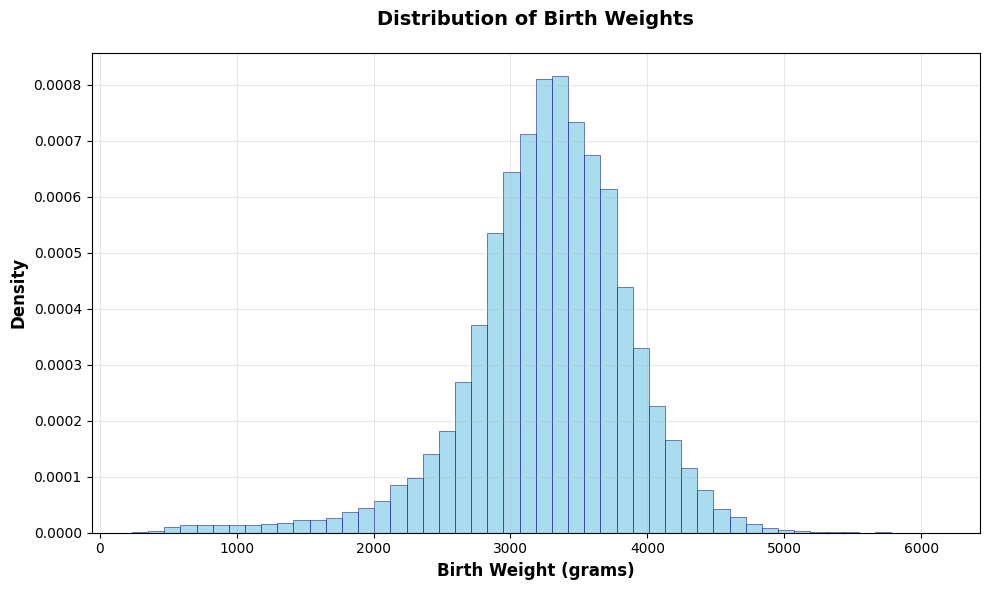

In [472]:
# birthweight histogrpah
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(natality["dbirwt"], bins=50, alpha=0.7, color='skyblue', 
                          edgecolor='navy', linewidth=0.5, density=True)
ax.set_xlabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Birth Weights', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# create full linear model
model = smf.ols('dbirwt ~ dgestat + wtgain + dmage + C(smoker) + C(bsex)'
'+ dgestat*wtgain + dgestat*dmage + wtgain*dmage '
'+ dgestat*wtgain*dmage', data=natality).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 dbirwt   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     6289.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:20:47   Log-Likelihood:            -8.8409e+05
No. Observations:              116037   AIC:                         1.768e+06
Df Residuals:                  116027   BIC:                         1.768e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1275.7226    210.499     -6.060      0.000   -1688.297    -863.149
C(smoker)[T.1]        -162.1299      8.068    -20.095      0.000    -177.944    -146.316
C(bsex)[T.1]          -121.3176      2.896    -41.891      0.000    -126.994    -115.641
dgestat                107.5945      5.440     19.779      0.000      96.932     118.257
wtgain                  64.2542      6.746      9.524      0.000      51.031      77.477
dmage                  -29.6615      7.277     -4.076      0.000     -43.924     -15.399
dgestat:wtgain          -1.4662      0.173     -8.458      0.000      -1.806      -1.126
dgestat:dmage            0.9926      0.188      5.268      0.000       0.623       1.362
wtgain:dmage            -1.4603      0.235     -6.214      0.000      -1.921      -1.000
dgestat:wtgain:dmage     0.0363      0.006      6.002      0.000       0.024       0.048
==============================================================================
Omnibus:                     2269.866   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4904.650
Skew:                          -0.020   Prob(JB):                         0.00
Kurtosis:                       4.006   Cond. No.                     5.56e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.56e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# create reduced linear model
model_red = smf.ols('dbirwt ~ dgestat + wtgain + dmage + C(smoker) + C(bsex)', data=natality).fit()

display(model_red.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 dbirwt   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                 1.110e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:20:47   Log-Likelihood:            -8.8445e+05
No. Observations:              116037   AIC:                         1.769e+06
Df Residuals:                  116031   BIC:                         1.769e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1851.8446     23.286    -79.525      0.000   -1897.485   -1806.204
C(smoker)[T.1]  -165.3244      8.092    -20.431      0.000    -181.184    -149.464
C(bsex)[T.1]    -121.4559      2.905    -41.807      0.000    -127.150    -115.762
dgestat          123.5750      0.564    219.145      0.000     122.470     124.680
wtgain             5.8454      0.112     52.340      0.000       5.627       6.064
dmage              7.2886      0.228     31.947      0.000       6.841       7.736
==============================================================================
Omnibus:                     2189.016   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4659.214
Skew:                          -0.018   Prob(JB):                         0.00
Kurtosis:                       3.981   Cond. No.                         931.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# compare models
anova_results = anova_lm(model_red, model)
display(anova_results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,116031.0,2.835713e+10,0.0,NaN,NaN,NaN
1,116027.0,2.817731e+10,4.0,1.798164e+08,185.109597,1.965984e-158


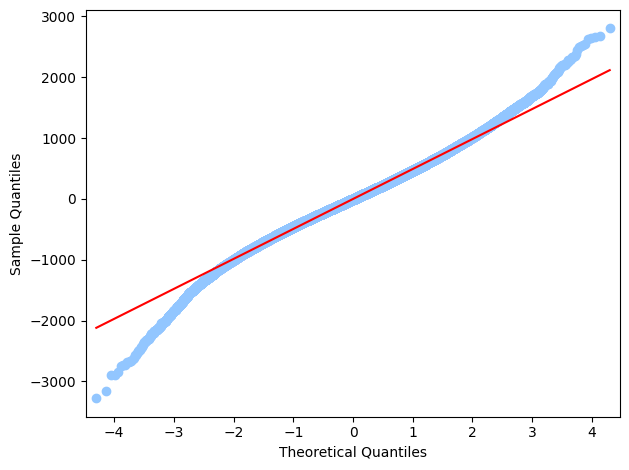

In [466]:
# call residulals from model
residuals = model.resid
# show qq plot
fig = sm.qqplot(residuals, line='s')
plt.tight_layout()
plt.show()

In [ ]:
# predict birth weights
predictions = model_red.predict(natality)

# compare descriptive statistics of actuals vs predictions
display(natality['dbirwt'].describe())
display(predictions.describe())

count    116037.000000
mean       3274.106880
std         601.076042
min         235.000000
25%        2977.000000
50%        3317.000000
75%        3645.000000
max        6135.000000
Name: dbirwt, dtype: float64

count    116037.000000
mean       3274.106880
std         341.921425
min         440.553696
25%        3136.939432
50%        3313.540377
75%        3470.381430
max        4610.358981
dtype: float64

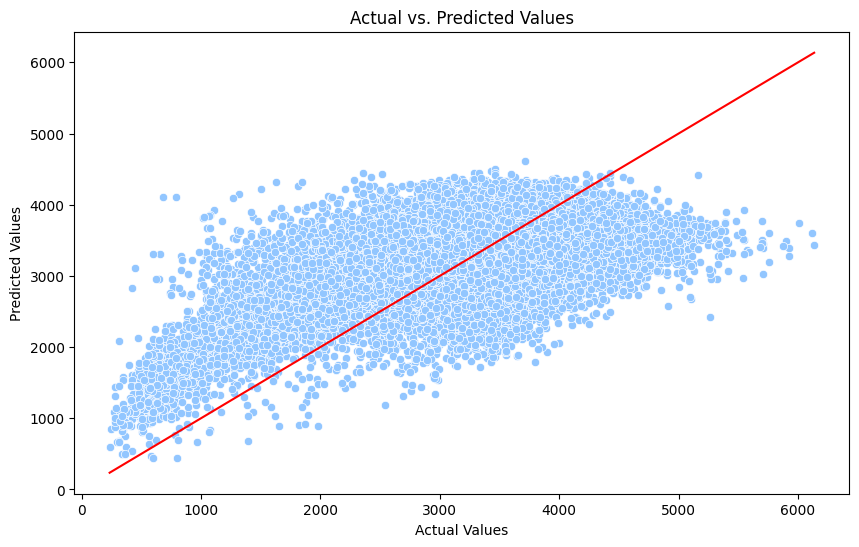

In [ ]:
# actuals vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=natality['dbirwt'], y=predictions)
plt.plot([min(natality['dbirwt']), max(natality['dbirwt'])], [min(natality['dbirwt']), max(natality['dbirwt'])], color='red', linestyle='-') # y=x line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()